In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [2]:
with open('data_simple_line_perturbed_2D_1000_turns.pkl', 'rb') as f:
    data = pickle.load(f)

In [3]:
data.keys()

dict_keys(['x', 'px'])

In [ ]:
# Choose a particle index
particle_idx = 0

In [13]:
# Extract position and momentum time series for this particle
x_series = data['x'][particle_idx, :100]
px_series = data['px'][particle_idx, :100]

In [15]:
x_series.shape

(100,)

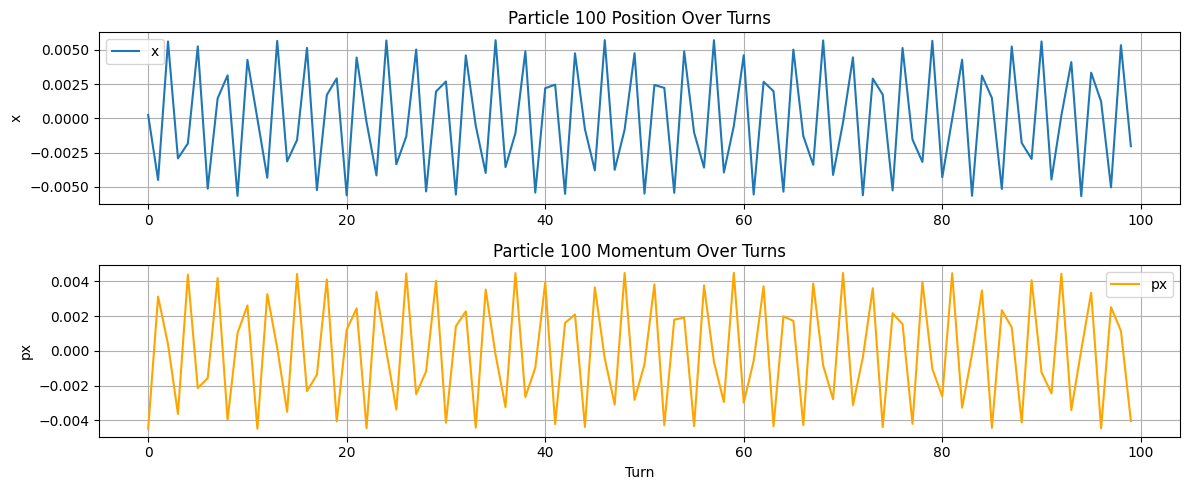

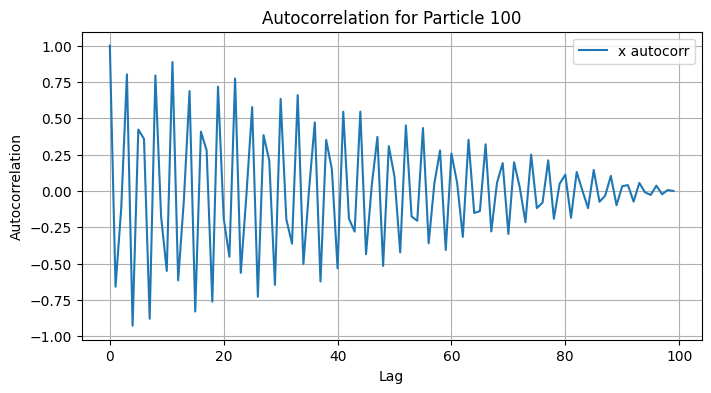

In [14]:
# Plot position and momentum over turns
plt.figure(figsize=(12, 5))
plt.subplot(2, 1, 1)
plt.plot(x_series, label='x')
plt.title(f'Particle {particle_idx} Position Over Turns')
plt.ylabel('x')
plt.grid()
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(px_series, label='px', color='orange')
plt.title(f'Particle {particle_idx} Momentum Over Turns')
plt.xlabel('Turn')
plt.ylabel('px')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Optional: Plot autocorrelation to check periodicity
def autocorr(x):
    result = np.correlate(x - np.mean(x), x - np.mean(x), mode='full')
    return result[result.size // 2:] / result[result.size // 2]

plt.figure(figsize=(8, 4))
plt.plot(autocorr(x_series), label='x autocorr')
# plt.plot(autocorr(px_series), label='px autocorr')
plt.title(f'Autocorrelation for Particle {particle_idx}')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid()
plt.legend()
plt.show()

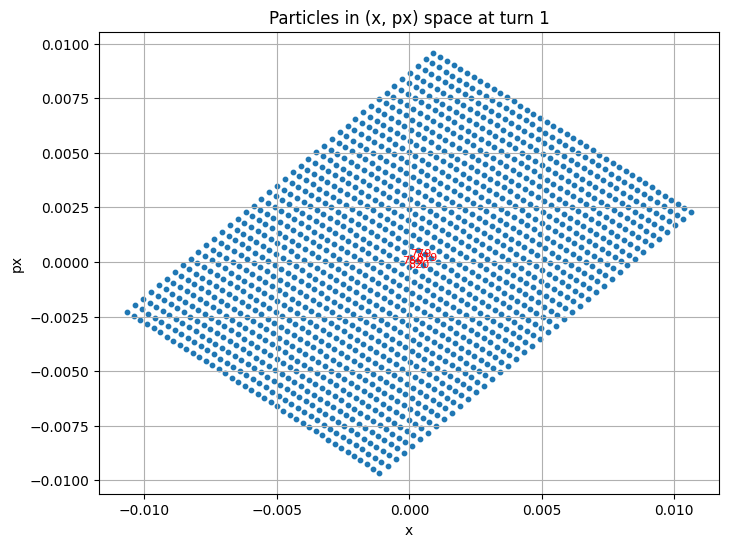

In [47]:
turn = 1  # Choose the turn to inspect (e.g., 0 for initial state)
x_vals = data['x'][:, turn]
px_vals = data['px'][:, turn]

plt.figure(figsize=(8, 6))
plt.scatter(x_vals, px_vals, s=10, color='C0')

# Annotate only the specified indices in the plot
indices_to_label = [779, 780, 819, 820] # Example indices to label
# indices_to_label = range(700,900)
for idx in indices_to_label:
    plt.annotate(str(idx), (x_vals[idx], px_vals[idx]), fontsize=8, color='red')

plt.xlabel('x')
plt.ylabel('px')
plt.title(f'Particles in (x, px) space at turn {turn}')
plt.grid()
plt.show()

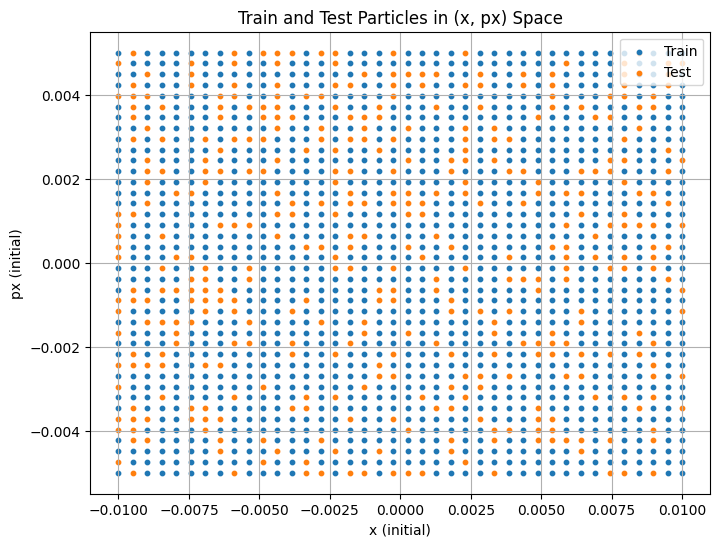

In [52]:
np.random.seed(42)  # For reproducibility

num_particles = data['x'].shape[0]  # Should be 1600
train_size = 1200

# Randomly select indices for training particles
train_indices = np.random.choice(num_particles, size=train_size, replace=False)

# remaining indices are used for testing
test_indices = np.setdiff1d(np.arange(num_particles), train_indices)

# Use these indices to select particles
x_train = data['x'][train_indices, :]
px_train = data['px'][train_indices, :]

x_test = data['x'][test_indices, :]
px_test = data['px'][test_indices, :]

# Plot the train and test particles in (x, px) space
plt.figure(figsize=(8,6))
plt.scatter(x_train[:, 0], px_train[:, 0], s=10, color='C0', label='Train')
plt.scatter(x_test[:, 0], px_test[:, 0], s=10, color='C1', label='Test')
plt.xlabel('x (initial)')
plt.ylabel('px (initial)')
plt.title('Train and Test Particles in (x, px) Space')
plt.legend()
plt.grid()
plt.show()

In [ ]:
77, 78, 81, 82

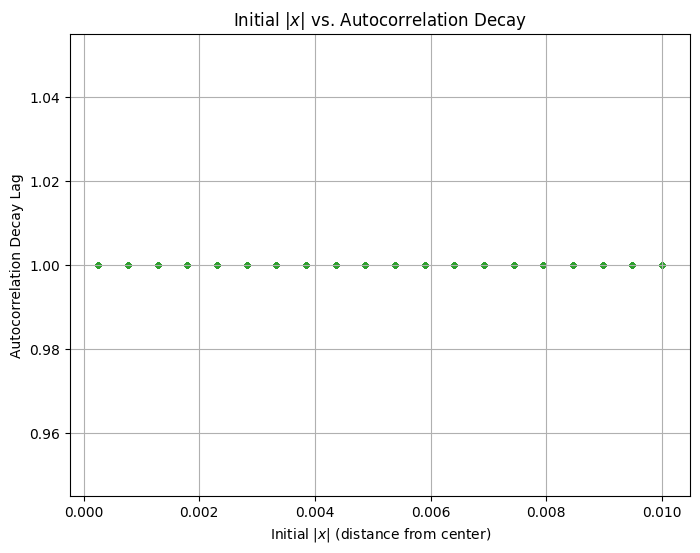

In [19]:
def autocorr(x):
    result = np.correlate(x - np.mean(x), x - np.mean(x), mode='full')
    return result[result.size // 2:] / result[result.size // 2]

num_particles = data['x'].shape[0]

# Store initial |x| and autocorr decay for each particle
initial_x = []
autocorr_decay = []

for i in range(num_particles):
    x0 = data['x'][i, 0]
    initial_x.append(np.abs(x0))  # Distance from center in x only

    x_series = data['x'][i, :]
    ac = autocorr(x_series)
    # Find lag where autocorr drops below 1/e
    below = np.where(ac < 1/np.e)[0]
    decay = below[0] if len(below) > 0 else len(ac)
    autocorr_decay.append(decay)

# Scatter plot: initial |x| vs autocorr decay
plt.figure(figsize=(8,6))
plt.scatter(initial_x, autocorr_decay, s=10, color='C2')
plt.xlabel('Initial $|x|$ (distance from center)')
plt.ylabel('Autocorrelation Decay Lag')
plt.title('Initial $|x|$ vs. Autocorrelation Decay')
plt.grid()
plt.show()

In [20]:
x_series

array([ 0.01      , -0.00113004, -0.00877874, ..., -0.01204224,
        0.00559685,  0.00447025], shape=(1001,))